## 第4章: 从头实现GPT模型

### 4.1 大语言模型框架的构建 ###

这张图展示了大语言模型的基本结构，输入文本先经过分词得到token序列。token进入嵌入层，嵌入层的规模由词汇表大小决定（词汇表包含训练语料中所有不同 token），每个token会被映射成向量表示。同时加入位置嵌入，位置嵌入的长度由上下文大小决定，用来表示token在序列中的位置。

随后，向量表示会依次通过多个Transformer模块。每个模块的关键组件是*掩码多头注意力*，掩码保证模型只能关注当前位置之前的token，多头机制让模型从不同角度建模上下文关系。最后接上输出层，把模型的表示映射到词汇表空间，得到下一个token的预测分布，用于生成文本。

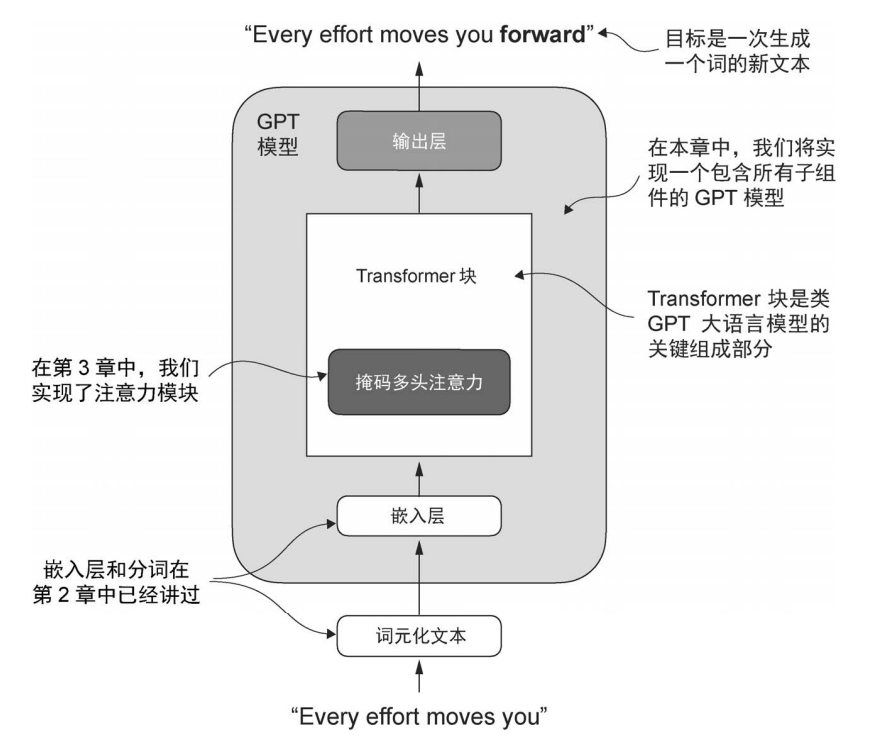

GPT-2（1.24 亿参数）模型的配置细节包括：

In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # 词汇表大小（token 总数）
    "context_length": 1024, # 上下文长度（一次最多处理的 token 数）
    "emb_dim": 768,         # 嵌入维度（每个 token 向量的长度）
    "n_heads": 12,          # 注意力头数（多头注意力的 head 数量）
    "n_layers": 12,         # Transformer 层数（block 的数量）
    "drop_rate": 0.1,       # Dropout 概率（训练时用于防止过拟合）
    "qkv_bias": False       # Q/K/V 线性映射是否使用 bias（是否加偏置项）
}

In [2]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
      #一个“简化版/占位符”的 GPT 模型骨架（Dummy = 只是结构，不实现真正的 Transformer 计算）
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        # 堆叠 n_layers 个 Transformer block（这里每层是占位层，不改变输入），重复执行n次
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x

输入层把词汇表大小对应的token映射到嵌入空间，得到连续的向量表示；输出层再把嵌入空间的表示投影回词汇表大小的空间，输出每个 token的预测分布，从而实现词的生成。在前向传播过程中，我们会把这些组件串联起来，形成Transforme的基本架构。

例如，当我们有若干条输入文本时，可以使用前面介绍的tiktoken分词器对它们进行分词，并在此基础上加载数据、组装成一个小batch，用于后续模型计算。

In [3]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


可以看到，这些文本会被转换成对应的 token id 序列，它们就是LLM在训练时实际接收的输入。接下来模型基于这些输入进行生成：在推理时逐步生成后续内容；在预训练时则以“预测下一个token”为目标，对序列中的下一步进行预测。

In [4]:
torch.manual_seed(123)
model = DummyGPTModel(cfg=GPT_CONFIG_124M)

logits = model(batch) # 模型的输出通常被称为logits
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


在深度学习中，模型最后通常会接一个线性层，其输出的一组数值称为 logits。logits 是未经过 softmax 归一化的原始打分，用来表示模型对各个类别（或词汇表中各个 token）的预测倾向。

模型的输出是一个很大的张量，形状为 2×4×50257：其中 2 表示 batch 大小，4 表示序列长度，50257 对应词汇表大小，也就是每个位置都会输出对全部 token 的一组 logits（打分）。接下来训练的目标是优化模型参数，让 LLM 学会根据已给出的 token 序列去预测“下一个 token”。

在生成时，当我们输入一段 token id 序列，模型会在对应位置输出一条长度为 50257 的 logits 向量；我们从中选取得分最高的那个 token（或按某种采样策略选择），得到它的 token id，然后再通过解码器把 token id 还原成可读文本。

### 4.2 使用层归一化进行归一化激活 ###

**层归一化（Layer Normalization，简称 LayerNorm）** 最早在 2016 年提出，用于在层与层之间对输出进行归一化处理，使送入下一层的表示更稳定，从而改善优化过程并提升训练效果。

In [5]:
torch.manual_seed(123)

batch_example = torch.randn(2,5)
batch_example

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])

我们先生成一个形状为 2×5 的随机样本（只是为了让示例更小、更直观），把它送入一个小型神经网络得到输出。通常我们希望这些输出落在相对稳定的取值范围内，因为它们会作为下一层的输入。如果只使用普通网络层，输出可能出现均值和方差不受控的情况；在这个例子里，输出的均值约为 0.13、方差约为 0.39，看起来还可以，但在更深的网络中，数值分布可能随着层数累积而变得过大或过小，从而引发训练不稳定，例如梯度消失或梯度爆炸。

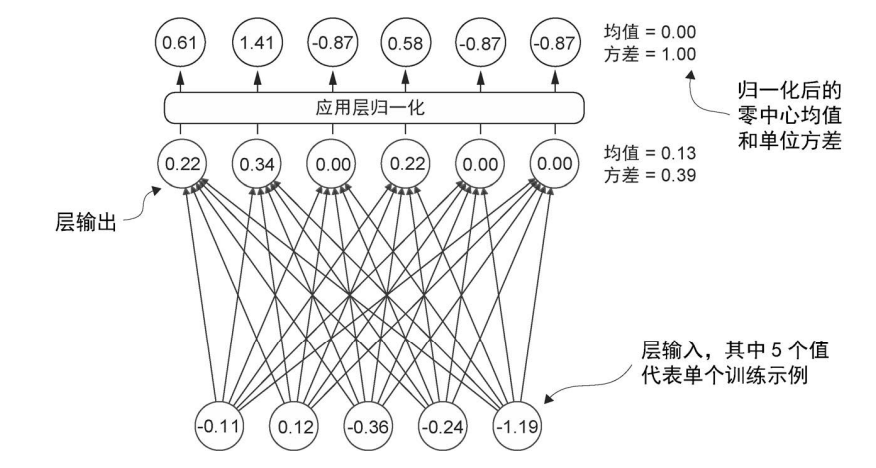

因此，我们会在层与层之间加入一种专门的归一化操作——**层归一化** 。它会对给定层的输出进行标准化，使其在进入下一层之前具有更稳定的分布，例如把输出调整到均值接近 0、方差接近 1，从而帮助稳定训练过程。

In [6]:
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())  # 定义一个小型前馈网络（两层按顺序串起来）：
                                                  # 线性层 Linear(5 -> 6)：把每个样本的特征维度从 5 映射到 6
                                                  # ReLU 激活：把线性层的输出做非线性变换（负数变 0，正数保持不变）
out = layer(batch_example)
out

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

从技术角度看，我们通常会在网络中加入非线性元素，例如使用 `ReLU` 这类非线性激活函数，并把它与线性层配合使用。原因是如果神经网络只包含线性层，那么无论叠加多少层，整体仍然等价于一个线性函数，表达能力有限，难以学习复杂模式。引入非线性后，模型才能刻画更复杂的映射关系，从而学到更丰富的特征与规律。

`ReLU`是神经网络中的一种标准激活函数。如果你不熟悉 ReLU，可以这样来理解：它只是简单地将负输入值设为 0，从而确保层的输出值都是正值，这也解释了为什么结果层的输出中不包含负值。之后，我们将在 GPT 中使用一种更复杂的激活函数。

In [7]:
mean = out.mean(dim=-1, keepdim=True)
mean

tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)

In [8]:
var = out.var(dim=-1, keepdim=True)
var

tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)

我们的目标是对数据做规范化处理。若对一组输出减去其均值，就能把数据平移到以均值为中心，使输出围绕 0 附近分布。

In [9]:
(out - mean).mean(dim=-1, keepdim=True)

tensor([[-7.4506e-09],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)

In [10]:
torch.set_printoptions(sci_mode=False)

`torch.set_printoptions(sci_mode=False)` 用来设置 PyTorch 张量在打印/显示时的格式，其中`sci_mode`控制是否使用科学计数法。

In [11]:
(out - mean).mean(dim=-1,keepdim=True)

tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)

接下来我们还希望把数据的方差调整为 1，因此需要将其除以标准差（即方差的平方根），完成标准化。

In [12]:
normed = (out - mean) / torch.sqrt(var)
normed.var(dim=-1, keepdim=True)

tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)

让我们先做一个简化版的LayerNorm，核心思想是对每个样本在特征维度上进行标准化，使输出的分布更稳定，然后再用两个可学习参数把标准化后的结果重新**缩放和平移**，以保留模型的表达能力。

在初始化中，我们先设定一个很小的常数`eps=1e-5`，用于后续计算时避免除零。接着定义两个可学习参数,`scale`和`shift`，它们的长度都是`emb_dim`。**`scale`初始为全1，表示一开始不改变尺度；`shift`初始为全 0，表示一开始不做平移。** 之所以要引入这两个参数，是因为单纯的标准化会强行把数据固定到均值为0、方差为1的分布，而`scale`和`shift`允许模型在需要时恢复或调整到更合适的数值范围。

In [21]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True)#, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps) # 再通过可学习的 scale/shift 做缩放和平移，恢复/调整表达能力
                                                         # scale、shift 会沿 batch/seq 维度自动广播到 x 的形状
        return self.scale * norm_x + self.shift

In [22]:
ln = LayerNorm(6)
outputs_normed = ln(out)

In [23]:
outputs_normed

tensor([[ 0.6157,  1.4123, -0.8717,  0.5871, -0.8717, -0.8717],
        [-0.0189,  0.1121, -1.0875,  1.5171,  0.5647, -1.0875]],
       grad_fn=<AddBackward0>)

In [24]:
outputs_normed.mean(dim=-1, keepdim=True)

tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)

In [25]:
outputs_normed.var(dim=-1, keepdim=True)

tensor([[0.9996],
        [0.9997]], grad_fn=<VarBackward0>)

在 LLM/Transformer的LayerNorm里，`unbiased=False`更常见，也和PyTorch的`nn.LayerNorm`做法一致；只有在确实需要统计意义上的“无偏估计”，或要和某段实现严格对齐时，才会用`unbiased=True`。两者的差别主要是一个固定比例,特征维度为 N 时，`unbiased=True`的方差会比`unbiased=False`大约 $\frac{N}{N-1}$，对应标准差相差 $\sqrt{\frac{N}{N-1}}$ 。所以 N 很大（如 768）时差异几乎可以忽略，但 N 很小（如教学案例中的 5）时差异会明显一些。

### 4.3 实现具有 GELU 激活函数的前馈神经网络###

在深度学习里，ReLU因结构简单、计算高效、在多种网络架构中表现稳定而被广泛使用。不过在LLM 中，除了传统的ReLU，还常用更适合深层模型的激活函数，例如GELU和SwiGLU。它们通常比ReLU更“平滑”、形式也更复杂，GELU融合了高斯分布相关的平滑非线性，SwiGLU则引入了基于sigmoid的门控机制。相较于ReLU的分段线性形式，这类激活函数往往能带来更好的训练与性能表现，尤其在深层网络中更常见。

In [27]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        """
        tanh 近似公式：
        GELU(x) ≈ 0.5 * x * (1 + tanh( sqrt(2/pi) * (x + 0.044715 * x^3) ))
        其中 0.044715 是经验常数，sqrt(2/pi) 是缩放系数
        """
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

我们可以用 Matplotlib 将该激活函数可视化：在例如 [−3,3] 的输入范围内生成一组样本数据，计算对应的输出曲线。为了对比其特性，也可以在同一张图中同时绘制 PyTorch 的 ReLU 曲线，便于观察两者在负区间与正区间的差异。

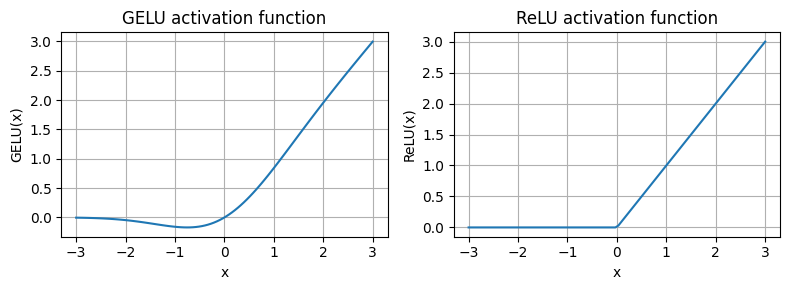

In [29]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

从图中可以看出，ReLU 是一种分段线性函数：当输入为正时直接输出输入本身；当输入为负时输出 0。相比之下，GELU 是更平滑的非线性函数，它在整体形态上近似 ReLU，但在负值区间通常仍保留非零梯度（大约在 −0.75 附近梯度接近 0），因此在训练时对负输入也能提供一定的学习信号。

接下来我们将实现一个小型神经网络模块`FeedForward`，它会在后续作为大语言模型Transformer Block的组成部分使用。

这个前馈模块`FeedForward`通常用`Sequential`组织起来，表示在前向传播时会按顺序依次执行其中的各个子层。它的核心结构一般是两层线性变换：先把嵌入维度从 768 扩展到 3072，再从 3072 投影回 768。这样的“先扩维再降维”会引入大量可训练参数，使模型在更高维的中间空间里学习更复杂的特征变换。

In [35]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),  
            # 扩展维度，把每个 token 的表示从 emb_dim 扩展到 4*emb_dim（增加表达能力与参数量）
            GELU(),
            # 非线性激活,这里使用GELU，引入非线性表达能力
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
            # 投影回原维度，把 4*emb_dim 再映射回 emb_dim，方便与残差连接等结构配合
        )

    def forward(self, x):
        return self.layers(x)

我们可以用一些示例数据来测试一下。

In [33]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768) 
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


### 4.4 添加残差连接 ### 

在这一部分我们引入残差链接（Residual Connection，也常称快捷连接）。它的出发点是深层网络训练中的典型困难：网络越深，反向传播路径越长，梯度在层层传递中容易逐渐变小导致梯度消失，或在某些情况下变得过大造成梯度爆炸。结果就是部分层可能几乎学不到有效东西（梯度接近 0），或者训练过程非常不稳定。

残差链接的形式很直接：让子模块的输入 x 在经过变换 F(x) 后，与原始输入相加得到 
F(x)+x。这样即使某个子模块一时表现不好、输出 F(x) 很弱甚至接近无效，信息仍然可以通过 x 这条“直达通道”向前传递；在反向传播时，梯度也能沿着更短的路径回传，从而更容易保留梯度信号，缓解深层结构中梯度衰减的问题。换句话说，残差链接为网络提供了一个不会削弱表示的“兜底路径”，在训练中起到稳定与保底的作用。

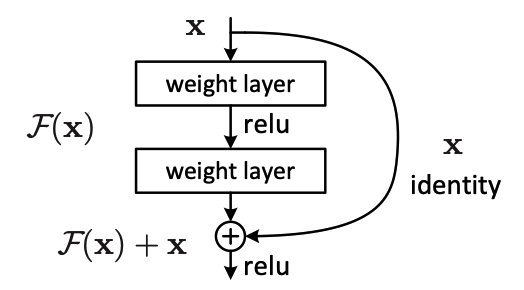

从整体结构看，深度网络的层是顺序堆叠且彼此依赖的：如果中间某个子模块失效或输出异常，后续所有层都会受到影响。残差链接相当于给网络增加一条旁路，使模型不至于因为某一层暂时学不好而“卡住”，从而让训练更稳定、收敛更容易。在 Transformer 中，残差链接通常与 LayerNorm 搭配使用，用来进一步稳定数值分布并提升可训练性。

In [44]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        """
        layer_sizes: 每一层的宽度列表，例如 [5, 10, 10, 10, 10, 1]
                 表示输入维度=5，接着 5->10->10->10->10->1 共 5 个线性层
        use_shortcut: 是否启用残差链接（当输入输出 shape 相同才进行相加）
        """
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([  # ModuleList 用来存储多个子模块（这里是 5 个“Linear + GELU”的小层）
                                       # 注意：之所以用 ModuleList 而不是普通 list，是为了让 PyTorch 正确注册参数
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        """
        逐层计算 layer_output = layer(x)
        若启用残差链接且 x 与 layer_output 的形状一致，则做 x = x + layer_output
          （形状一致是为了保证相加合法）
        否则直接用 x = layer_output
        """
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output # 不用残差时，正常把输出传给下一层
        return x


def print_gradients(model, x):
    """
    用于打印模型各层权重参数的梯度大小（平均绝对值），观察梯度是否衰减/爆炸。
   
    步骤：
    (1) 前向传播得到 output
    (2) 构造一个目标 target（这里设为 0）
    (3) 用 MSELoss 计算 loss
    (4) 反向传播 loss.backward() 计算梯度
    (5) 遍历模型参数，打印每个 weight 的梯度均值
    """
    output = model(x)   # 构造监督信号/目标值：这里用一个标量 0（shape = (1, 1)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()  # 定义均方误差损失函数
    loss = loss(output, target)  # 计算 loss：衡量 output 与 target 的差距
    
    loss.backward()  # 反向传播：根据 loss 计算每个可学习参数的梯度，结果存到 param.grad

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

在上面的代码中，我们定义了一个实用函数`print_gradients`来观察深层网络中的梯度情况。它首先对输入做一次前向传播得到模型输出 `output`，同时构造一个`target`作为目标值；这里的`target`主要是占位符，用来演示训练流程。深度神经网络的训练通常遵循同样的机制：先用损失函数比较“模型输出”和“目标值”的差异，损失值可以看作二者相似程度（或误差大小）的度量；然后基于这个损失执行反向传播（backward），把误差信号传回各层参数，从而得到梯度并用于后续优化。

需要注意的是，这段示例代码里使用的是 **均方误差损失（MSELoss)** 来演示梯度计算；而在大语言模型的预训练/预测下一个token的任务中，更常用的是 **交叉熵损失（Cross-Entropy Loss）**，因为模型输出的是对词汇表各token的概率分布（logits），交叉熵更适合衡量预测分布与真实标签之间的差异。

下面我们先在不使用残差链接的情况下，打印并观察梯度值。

In [45]:
layer_sizes = [3, 3, 3, 3, 3, 1]  

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041071094573
layers.3.0.weight has gradient mean of 0.0013988735154271126
layers.4.0.weight has gradient mean of 0.005049645435065031


可以看到此时各层的梯度数值都非常小。接下来我们将`use_shortcut`打开，引入残差链接，再观察梯度的变化。

In [46]:
layer_sizes = [3, 3, 3, 3, 3, 1]  

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


现在可以看到梯度数值明显变大了。通过引入残差链接，梯度能够更顺畅地在网络中传播，从而缓解深层网络中梯度过小的问题。在后续的优化过程中，我们需要依赖这些梯度去更新各层的权重矩阵；当训练出现不稳定或某些子模块暂时学不好时，残差链接提供了一条稳定的旁路，起到补偿与兜底作用，避免训练信号被彻底削弱，帮助网络维持可训练性。

### 4.5 连接Transformer模块中的注意力层和线性层 ###

现在我们已经具备编写 Transformer 模块代码所需的基础组件。Transformer 模块会把多个关键结构整合在一起，包括注意力机制（尤其是多头注意力模块）以及前馈网络中使用的一系列线性层等。到目前为止，我们已经掌握了这些构建模块的实现思路，因此接下来就可以开始组合它们，编写完整的 Transformer 模块代码。

In [50]:
from previous_chapters import MultiHeadAttention 
# 从前面章节实现的 MultiHeadAttention 模块中导入，用于在此处组装完整的 TransformerBlock 

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention( # 多头注意力模块
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg) # 前馈网络
        self.norm1 = LayerNorm(cfg["emb_dim"])  # 两个 LayerNorm
        self.norm2 = LayerNorm(cfg["emb_dim"])  # norm1 用于注意力子模块前；norm2 用于前馈子模块前
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"]) # 残差分支上的 dropout（也可理解为对每个子模块输出再做一次 dropout）

    def forward(self, x):
        shortcut = x                # 保存残差分支的“原始输入”，用于后面相加
        x = self.norm1(x)           # Pre-LN：先做 LayerNorm，稳定数值分布，便于训练
        x = self.att(x)             # 多头自注意力：让每个位置根据上下文聚合信息
        x = self.drop_shortcut(x)   # 对注意力输出做 dropout（训练时）
        x = x + shortcut            # 残差链接：把注意力输出与原输入相加，保留信息与梯度通路

        shortcut = x                # 再次保存当前 x 作为残差分支输入
        x = self.norm2(x)           # Pre-LN：先归一化再进入 FFN
        x = self.ff(x)              # FFN：逐位置的非线性变换（不在序列维做混合）
        x = self.drop_shortcut(x)   # 对 FFN 输出做 dropout（训练时）
        x = x + shortcut            # 残差链接：把 FFN 输出与该子层输入相加

        return x

这段代码就是把一个TransformerBlock的“标准搭积木方式”拼接在一起，先做多头注意力，再做前馈网络。每一块前面都先过一次 LayerNorm（这就是常说的 Pre-LN），让输入的数值更稳定，训练更不容易发散。

然后模块算完以后，会做一次 Dropout，最后再把模块输出和原来的输入相加，这一步就是残差链接，它的作用是给信息和梯度留一条“直通车”，就算某一层暂时学得不好，也不会把整个网络卡死。

因为注意力模块和 FFN 的输入输出维度都保持在`emb_dim`，所以才能直接做相加，也方便把很多个这样的 Block 一层层堆起来，组成完整的 Transformer。

### 4.6 实现GPT模型 ###

接下来把TransformerBlock接入本章一开始搭好的整体框架中，就能得到一个真正可用的GPT模型结构。需要注意的是，TransformerBlock并不是只用一次，而是会重复堆叠多层；例如在最小的 GPT-2 124M 配置中，这个模块会重复12次。

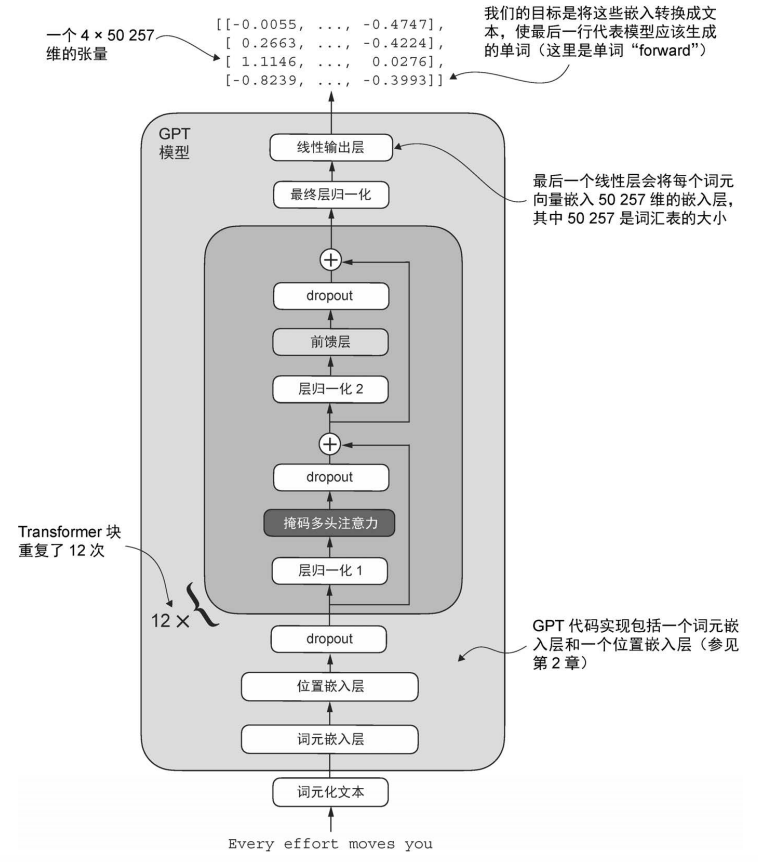

In [55]:
class GPTModel(nn.Module):
    """
    一个可用的 GPT 模型骨架：
    Token Embedding + Position Embedding
    -> 多层 TransformerBlock 堆叠
    -> 最终 LayerNorm
    -> 输出头（投影回词表大小，得到 logits）
    """
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        #Token Embedding：把 token id 映射成 emb_dim 维向量
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        #Position Embedding：把位置索引(0..context_length-1)映射成 emb_dim 维向量
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        # Embedding Dropout：对 embedding 做 dropout（训练时生效）
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        #多层 TransformerBlock：把 TransformerBlock 重复堆叠 cfg["n_layers"] 次
        self.final_norm = LayerNorm(cfg["emb_dim"])
        #最终 LayerNorm：在输出头之前再做一次归一化（GPT 常见做法）
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )
        #输出头：把 emb_dim 投影到 vocab_size，得到每个 token 的 logits
        #logits 是“未做 softmax 的打分”，后续可用于 CrossEntropyLoss 或采样生成
        
    def forward(self, in_idx):
        """
        前向传播：
        in_idx: (batch_size, seq_len) 的 token id
        返回:
        logits: (batch_size, seq_len, vocab_size)
               表示每个位置对词表中所有 token 的预测打分
        """
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

使用 124M 参数模型的配置，我们现在可以按下面的方式实例化这个 GPT 模型，并让它以随机初始化的权重开始运行。

In [56]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3612,  0.4223, -0.0709,  ...,  0.3479,  0.4655, -0.2833],
         [-0.1785, -0.5656, -0.9477,  ...,  0.0476,  0.5173, -0.3160],
         [ 0.7118,  0.0335,  0.1078,  ...,  0.1020, -0.4331, -0.2547],
         [-1.0068,  0.3420, -0.1191,  ...,  0.7193,  0.4018,  0.0532]],

        [[-0.2562,  0.0899,  0.0337,  ...,  0.2659,  0.4448, -0.6800],
         [ 0.1230,  0.3651, -0.2071,  ...,  0.7704,  0.2702,  0.2250],
         [ 1.0555,  1.0312, -0.2797,  ...,  0.6934,  0.3201, -0.3172],
         [-0.1559,  0.3922,  0.3286,  ...,  1.2627, -0.1862,  0.0391]]],
       grad_fn=<UnsafeViewBackward0>)


我们会在下一章训练这个模型。不过先简单说明一下它的规模：我们之前把它称为 1.24 亿（124M）参数模型，接下来可以用一段代码快速统计并验证模型的参数总量是否接近这个数值。

In [57]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


从上面的统计结果可以看到，这个实现的参数量是 163M，而不是我们常说的 124M，是因为在原始 GPT-2 论文中，研究者使用了**权重绑定（weight tying）**，也就是把输出层的权重与token嵌入层（tok_emb）的权重共享，做法等价于设置`self.out_head.weight = self.tok_emb.weight`。这样一来，模型不会为输出层再单独学习一套权重，从而显著减少参数量。

具体来说，token 嵌入层把维度为 50,257 的 one-hot token（可以理解为“词表位置”）映射到 768 维的嵌入向量；而输出层则把 768 维的隐藏表示再投影回 50,257 维，用于得到词表上每个 token 的打分并最终还原成文本。由于这两层的权重矩阵形状本质上是对应的（一个做“从词表到嵌入”，一个做“从嵌入回词表”），它们的参数数量也相同；如果不做权重绑定，就会把这部分参数算两遍，参数总量自然会从 124M 增加到更大的数（例如这里看到的 163M）。因此，我们通常称它为 124M 参数模型，指的是采用权重绑定后的 GPT-2 配置；我们也可以用代码再次统计并验证这个数字。

In [58]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


在原始 GPT-2 论文中，研究者将 token 嵌入矩阵复用为输出层矩阵（即权重绑定）。因此，如果我们从总参数量中减去输出层所带来的那部分独立参数数量，就会得到约 124M 参数的模型规模。

In [59]:
total_params_gpt2 =  total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


在实际训练中，不做权重绑定会更容易训练一些，所以这里先没有实现这一步。不过后续会在第5章加载预训练权重时再回到这个概念，并把权重绑定应用起来。最后，我们还可以用下面的方法估算模型的显存/内存占用，这可以作为一个有用的参考指标。

假设你已经计算过模型总参数量（整数），例如：`total_params = sum(p.numel() for p in model.parameters())`，这里直接使用`total_params`来估算“仅参数权重”占用的内存。注意：这不包含梯度、优化器状态（如 Adam 的动量）、激活值等额外开销。

In [62]:
total_size_bytes = total_params * 4
# 计算参数占用的总字节数
# 常见情况：float32（FP32）每个参数占 4 字节

total_size_mb = total_size_bytes / (1024 * 1024)
# 将字节数转换成 MB（MiB），即除以 1024*1024

print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


 - **GPT2-small** (the 124M configuration we already implemented):
        - "emb_dim" = 768
        - "n_layers" = 12
        - "n_heads" = 12

    - **GPT2-medium:**
        - "emb_dim" = 1024
        - "n_layers" = 24
        - "n_heads" = 16
    
    - **GPT2-large:**
        - "emb_dim" = 1280
        - "n_layers" = 36
        - "n_heads" = 20
    
    - **GPT2-XL:**
        - "emb_dim" = 1600
        - "n_layers" = 48
        - "n_heads" = 25

### 4.7 生成文本

以输入 “hello, I am” 为例，首先我们会像第二章那样用分词器把文本从字符串转换成 token id，也就是一串整数。接着把这串 token id 输入到我们刚刚实现的 GPT 模型中，模型会输出一个张量：序列里每个位置都会对应一行输出，分别表示模型在该位置对“下一步 token”的预测。

在训练时，我们的数据加载方式通常是把目标序列相对输入序列整体右移一位，也就是让模型在每个位置学习“用当前 token 去预测下一个 token”。因此，模型在位置 t 输出的向量，本质上就是对位置 t+1 的预测信息。这样一来，输入序列最后一个位置输出的那一行，就包含了“接下来要生成的下一个 token”所需的信息。现在的问题是：如何把这一行向量再转换回具体的词。

这行向量的数值来自最后的线性层输出，在神经网络里通常称为**logits**。我们取最后一个token对应的logits，并对它应用`softmax`做归一化，把原本取值范围在 (−∞,+∞) 的打分转换成概率分布：每个概率都为正，且总和为 1。生成时，我们希望选出概率最高的 token 作为下一个输出（例如贪心解码就是取最大概率对应的 token）。需要强调的是，这里模型还没有训练，所以预测未必合理；真正让“正确的下一个 token”概率变高的训练过程，会在下一章完成。最后，我们把新生成的token 追加到输入序列中，再把更新后的序列送回模型，重复这一过程，就能以迭代方式逐步生成文本。

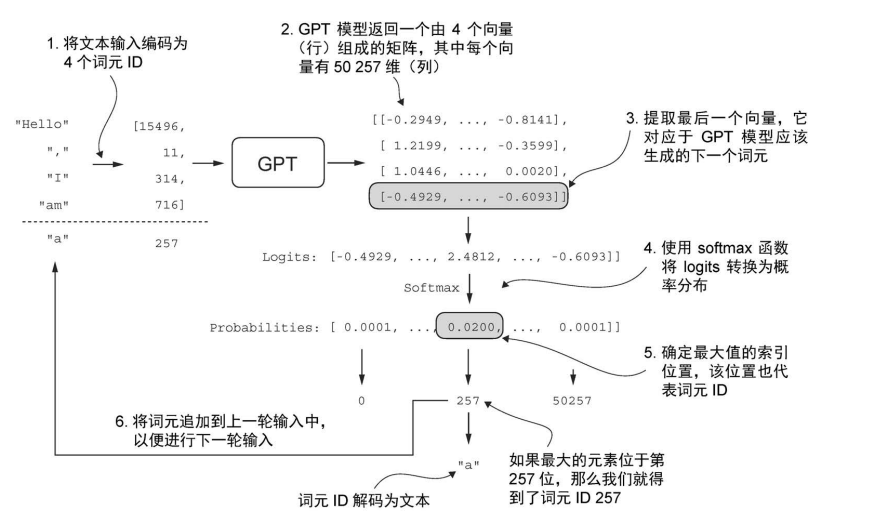

In [67]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    """
    使用“贪心解码（greedy decoding）”生成文本的简化函数。

    参数：
    - model: 已构建好的 GPT 模型，输入 token id 序列，输出每个位置的 logits
    - idx: 初始上下文的 token id，形状 (batch_size, seq_len)
    - max_new_tokens: 要生成的新 token 数量
    - context_size: 模型允许的最大上下文长度（超出时只截取最后 context_size 个 token）

    """
    for _ in range(max_new_tokens) :        
    
        idx_cond = idx[:, -context_size:]   # 截取模型可用的上下文窗口（只保留最后 context_size 个 token）
                                            # 这样可以避免输入长度超过模型的 context_length
         
        with torch.no_grad():       # 前向推理得到 logits（不计算梯度，加速并节省显存）
            logits = model(idx_cond)
        
        logits = logits[:, -1, :]   # 只取“最后一个位置”的 logits，因为我们要预测的是“下一个 token”
                                  
        probas = torch.softmax(logits, dim=-1)  # 将 logits 通过 softmax 转成概率分布（每个值 > 0，且总和为 1）

        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # 贪心解码：选择概率最大的 token 作为下一步输出

        idx = torch.cat((idx, idx_next), dim=1) # 把新生成的 token 拼接到原序列后面，作为下一轮的输入上下文

    return idx

这段`generate_text_simple`用的是贪心解码来生成文本：给定当前的token序列`idx`，循环`max_new_tokens`次，每次生成1个新 token并拼到序列末尾，最终返回更长的token序列。

每一步先用`idx[:, -context_size:]`截取最后`context_size`个token作为上下文，避免输入超过模型的上下文窗口。然后在 `torch.no_grad()`下前向推理得到logits，并只取最后一个位置`logits[:, -1, :]`，因为我们只关心“下一个 token”的预测。接着用`softmax`把logits转成概率分布，再用`argmax`选出概率最大的token作为`idx_next`，最后用`torch.cat`把它追加到输入里，进入下一轮生成。

下面先尝试一个输入示例。

In [68]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [70]:
model.eval()  # 将模型切换到评估模式（eval）
              # 关闭 Dropout、使用固定的 LayerNorm/BatchNorm 行为（如果有），保证推理结果稳定
out = generate_text_simple(
    model=model,               # 已实例化的 GPT 模型
    idx=encoded_tensor,        # 输入的 token id 张量，形状通常为 (batch_size, seq_len)
    max_new_tokens=6,          # 需要额外生成的 token 数量
    context_size=GPT_CONFIG_124M["context_length"]   # 上下文窗口大小（最多保留这么多 token）
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


这段代码是在做一次最基本的推理生成。`model.eval()`把模型切到评估模式，推理时会关闭`Dropout`，保证输出更稳定。接着调用 `generate_text_simple`，输入是已经分词好的`encoded_tensor`（token id 序列），让模型在当前上下文基础上再生成6个新 token；`context_size`设为配置里的`context_length`，用于限制每次送入模型的上下文窗口长度。函数返回的`out`仍然是 token id张量，`print("Output:", out)` 会直接打印这些id；`len(out[0])` 则查看batch中第一条序列的总长度（原始长度 + 生成的 6个token）。

然后让我们来去掉batch维度，并将结果解码还原为文本。

In [71]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


需要注意的是，这个模型目前还没有训练，因此上面生成的文本是随机、没有语义的输出。我们会在下一章对模型进行训练。